<font size=4> NEXAFS and Calculating Scattering Contrasts

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.polynomial
import glob
import shutil
from matplotlib.pyplot import cm

# Load and display magic angle NEXAFS

In [8]:
fTPD = '/home/cbishop/TPD-TCTA/SI_scripts/Final/Files_NEXAFS/TPDnex_20240109.txt'
fTCTA = '/home/cbishop/TPD-TCTA/SI_scripts/Final/Files_NEXAFS/TCTAnex_20240109.txt'
TPDnex = np.loadtxt(fTPD); TCTAnex = np.loadtxt(fTCTA)

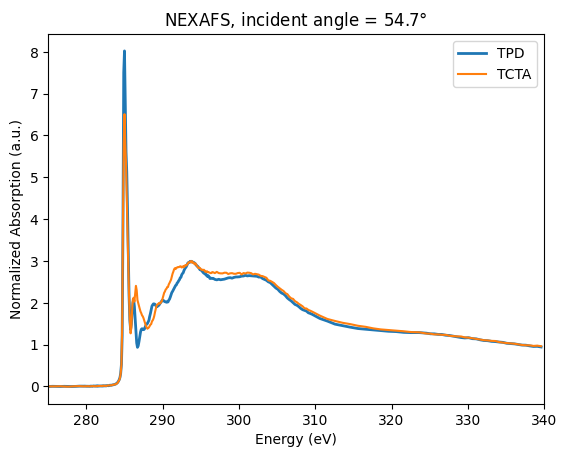

In [12]:
fig, ax = plt.subplots()
ax.plot(TPDnex[:,0],TPDnex[:,1],linewidth=2,label='TPD')
ax.plot(TCTAnex[:,0],TCTAnex[:,1],label='TCTA')
ax.legend()
ax.set_xlim(275,340)
ax.set_ylabel('Normalized Absorption (a.u.)')
ax.set_xlabel('Energy (eV)')
ax.set_title('NEXAFS, incident angle = $54.7 \degree$')
plt.savefig('NEXAFS_S12.png', dpi=200)

# Use kkcalc to calculate contrasts

In [13]:
from scipy.interpolate import interp1d

In [14]:
!pip install kkcalc

  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/3a/d0/edc009c27b406c4f9cbc79274d6e46d634d139075492ad055e3d68445925/numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 44.0 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompat

In [15]:
from kkcalc import kk
from kkcalc import data

In [20]:
x_min = 270
x_max = 340

chemformTPD = 'C38H32N2'
density = 1.14 # M. Shibata et. al. J. Mat. Chem. C 2015 DOI: 10.1039/C5TC01911G


output_kk = kk.kk_calculate_real(fTPD,
                            chemformTPD,
                            load_options=None,
                            input_data_type='Beta',
                            merge_points=[x_min, x_max],
                            add_background=False,
                            fix_distortions=False,
                            curve_tolerance=None,
                            curve_recursion=50)


stoich = kk.data.ParseChemicalFormula(chemformTPD)
formula_mass = data.calculate_FormulaMass(stoich)
ASF_E, ASF_Data = kk.data.calculate_asf(stoich)
ASF_Data2 = kk.data.coeffs_to_ASF(ASF_E, np.vstack((ASF_Data, ASF_Data[-1])))
delta_TPD = data.convert_data(output_kk[:,[0,1]],'ASF','refractive_index', Density=density, Formula_Mass=formula_mass)
beta_TPD = data.convert_data(output_kk[:,[0,2]],'ASF','refractive_index', Density=density, Formula_Mass=formula_mass)

In [21]:
x_min = 270
x_max = 340

chemformTCTA = 'C54H36N4'
density = 1.275 # T.J. Ferron et. al. ACS App. Mat. Int. 2022 DOI: 10.1021/acsami.1c19948


output_kk = kk.kk_calculate_real(fTCTA,
                            chemformTCTA,
                            load_options=None,
                            input_data_type='Beta',
                            merge_points=[x_min, x_max],
                            add_background=False,
                            fix_distortions=False,
                            curve_tolerance=None,
                            curve_recursion=50)


stoich = kk.data.ParseChemicalFormula(chemformTCTA)
formula_mass = data.calculate_FormulaMass(stoich)
ASF_E, ASF_Data = kk.data.calculate_asf(stoich)
ASF_Data2 = kk.data.coeffs_to_ASF(ASF_E, np.vstack((ASF_Data, ASF_Data[-1])))
delta_TCTA = data.convert_data(output_kk[:,[0,1]],'ASF','refractive_index', Density=density, Formula_Mass=formula_mass)
beta_TCTA = data.convert_data(output_kk[:,[0,2]],'ASF','refractive_index', Density=density, Formula_Mass=formula_mass)

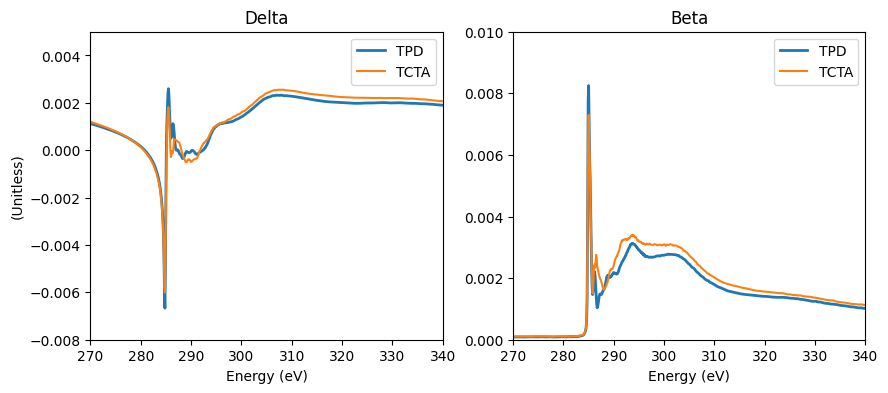

In [22]:
fig, [ax1,ax2] = plt.subplots(1,2,figsize=(10,4))
ax1.plot(delta_TPD[:,0],delta_TPD[:,1],linewidth=2,label='TPD')
ax1.plot(delta_TCTA[:,0],delta_TCTA[:,1],label='TCTA')
ax1.set_xlim(270,340);ax1.set_ylim(-0.008,0.005); ax1.legend()
ax1.set_title('Delta')
#plt.xlim(270,340); plt.ylim(-0.002,0.004)

ax2.plot(beta_TPD[:,0],beta_TPD[:,1],linewidth=2,label='TPD')
ax2.plot(beta_TCTA[:,0],beta_TCTA[:,1],label='TCTA')
ax2.set_xlim(270,340); ax2.set_ylim(0,0.01);ax2.legend()
ax2.set_title('Beta')
ax1.set_xlabel('Energy (eV)')
ax2.set_xlabel('Energy (eV)')
ax1.set_ylabel('(Unitless)')
plt.savefig('OCs_S12.png', dpi=200)

# Calculating binary contrasts from Optical Constants

In [23]:
interp_Es = np.linspace(270,340,701)

f_TPDB = interp1d(beta_TPD[:,0],beta_TPD[:,1])
TPD_Bint = f_TPDB(interp_Es)
f_TPDD = interp1d(delta_TPD[:,0],delta_TPD[:,1])
TPD_Dint = f_TPDD(interp_Es)

f_TCTAB = interp1d(beta_TCTA[:,0],beta_TCTA[:,1])
TCTA_Bint = f_TCTAB(interp_Es)
f_TCTAD = interp1d(delta_TCTA[:,0],delta_TCTA[:,1])
TCTA_Dint = f_TCTAD(interp_Es)

In [24]:
def calc_contrast(energies, Bmat1, Dmat1, Bmat2, Dmat2):
    contrast = []
    for i in range(0,len(Bmat1)):
        con_pt = (energies[i]**4)*((Dmat1[i]-Dmat2[i])**2 + (Bmat1[i]-Bmat2[i])**2)
        contrast.append(con_pt)
    return contrast

In [25]:
TPD_TCTA = calc_contrast(interp_Es,TPD_Bint, TPD_Dint, TCTA_Bint, TCTA_Dint)
TPD_vac = calc_contrast(interp_Es, TPD_Bint, TPD_Dint, np.zeros(len(TPD_Bint)), np.zeros(len(TPD_Bint)))
TCTA_vac = calc_contrast(interp_Es, TCTA_Bint, TCTA_Dint, np.zeros(len(TPD_Bint)), np.zeros(len(TPD_Bint)))

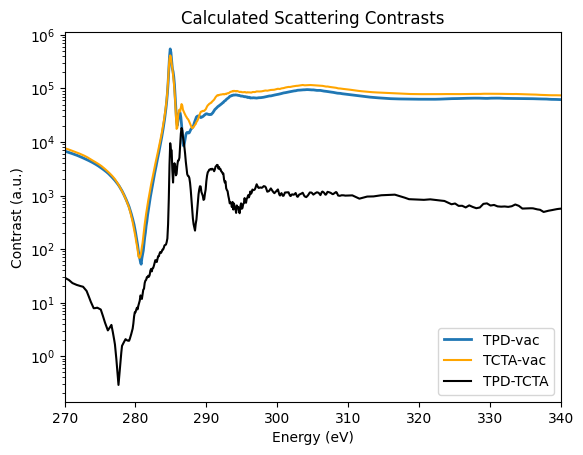

In [26]:
fig, ax = plt.subplots()
ax.plot(interp_Es, TPD_vac, color='tab:blue',linewidth=2,label='TPD-vac')
ax.plot(interp_Es, TCTA_vac, color='orange', label='TCTA-vac')
ax.plot(interp_Es, TPD_TCTA, color='k',label='TPD-TCTA')
ax.set_xlim(270,340)
ax.semilogy()
ax.legend()
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Contrast (a.u.)')
ax.set_title('Calculated Scattering Contrasts')
plt.savefig('BinaryContrasts_S13.png',dpi=200)

# Exploration of $\rho_{TPD}$ choice
We make a function to calculate variable densities of TPD.

In [28]:
def vardens_TPD(set_density):
    x_min = 270
    x_max = 340
    
    chemformTPD = 'C38H32N2'
    density = set_density
    
    
    output_kk = kk.kk_calculate_real(fTPD,
                                chemformTPD,
                                load_options=None,
                                input_data_type='Beta',
                                merge_points=[x_min, x_max],
                                add_background=False,
                                fix_distortions=False,
                                curve_tolerance=None,
                                curve_recursion=50)
    
    
    stoich = kk.data.ParseChemicalFormula(chemformTPD)
    formula_mass = data.calculate_FormulaMass(stoich)
    ASF_E, ASF_Data = kk.data.calculate_asf(stoich)
    ASF_Data2 = kk.data.coeffs_to_ASF(ASF_E, np.vstack((ASF_Data, ASF_Data[-1])))
    delta_TPD = data.convert_data(output_kk[:,[0,1]],'ASF','refractive_index', Density=density, Formula_Mass=formula_mass)
    beta_TPD = data.convert_data(output_kk[:,[0,2]],'ASF','refractive_index', Density=density, Formula_Mass=formula_mass)
    return delta_TPD, beta_TPD

Because some of the authors have calculated $\rho_{TCTA}$ using soft X-ray reflectivity in another publication (https://doi.org/10.1021/acsami.1c19948) to be 1.275 $g/cm^{3}$, we keep $\rho_{TCTA}$ constant. We repeat the same cell from above:

In [30]:
x_min = 270
x_max = 340

chemformTCTA = 'C54H36N4'
density = 1.275 


output_kk = kk.kk_calculate_real(fTCTA,
                            chemformTCTA,
                            load_options=None,
                            input_data_type='Beta',
                            merge_points=[x_min, x_max],
                            add_background=False,
                            fix_distortions=False,
                            curve_tolerance=None,
                            curve_recursion=50)


stoich = kk.data.ParseChemicalFormula(chemformTCTA)
formula_mass = data.calculate_FormulaMass(stoich)
ASF_E, ASF_Data = kk.data.calculate_asf(stoich)
ASF_Data2 = kk.data.coeffs_to_ASF(ASF_E, np.vstack((ASF_Data, ASF_Data[-1])))
delta_TCTA = data.convert_data(output_kk[:,[0,1]],'ASF','refractive_index', Density=density, Formula_Mass=formula_mass)
beta_TCTA = data.convert_data(output_kk[:,[0,2]],'ASF','refractive_index', Density=density, Formula_Mass=formula_mass)

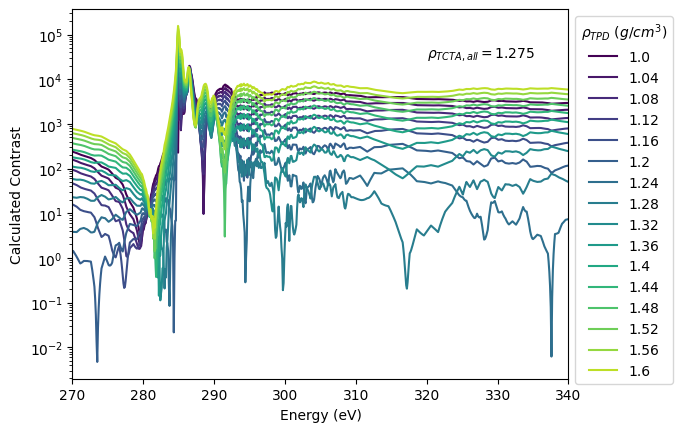

In [31]:
fig, ax = plt.subplots()
testrho = np.linspace(1.0,1.6,16)
pcol = iter(cm.viridis(np.linspace(0,0.9,len(testrho))))
for r in testrho:
    d_test, b_test = vardens_TPD(r)
    interp_Es = np.linspace(270,340,701)
    
    f_TPDB = interp1d(b_test[:,0],b_test[:,1])
    TPD_Bint = f_TPDB(interp_Es)
    f_TPDD = interp1d(d_test[:,0],d_test[:,1])
    TPD_Dint = f_TPDD(interp_Es)
    
    f_TCTAB = interp1d(beta_TCTA[:,0],beta_TCTA[:,1])
    TCTA_Bint = f_TCTAB(interp_Es)
    f_TCTAD = interp1d(delta_TCTA[:,0],delta_TCTA[:,1])
    TCTA_Dint = f_TCTAD(interp_Es)
    TPD_TCTA = calc_contrast(interp_Es,TPD_Bint, TPD_Dint, TCTA_Bint, TCTA_Dint)
    ax.plot(interp_Es,TPD_TCTA,color=next(pcol),label=round(r,2))

ax.semilogy()
ax.legend(bbox_to_anchor=(1,1),title=r'$\rho_{TPD}$ ($g/cm^{3}$)')
ax.set_xlabel('Energy (eV)'); ax.set_ylabel('Calculated Contrast')
ax.set_xlim(270,340)
ax.text(320, 10**4.5, r'$\rho_{TCTA,all}=1.275$')
plt.savefig('ChangingContrast_S14.png', dpi=200,bbox_inches='tight')